C:\Users\theep\AppData\Local\Temp\ipykernel_47652\1657119435.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(title="Task / $n_{init}$", bbox_to_anchor=(1.02, 1), loc="upper left")
C:\Users\theep\AppData\Local\Temp\ipykernel_47652\1657119435.py:164: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
C:\Users\theep\AppData\Local\Temp\ipykernel_47652\1657119435.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Clustering Metric")
C:\Users\theep\AppData\Local\Temp\ipykernel_47652\1657119435.py:199: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argumen

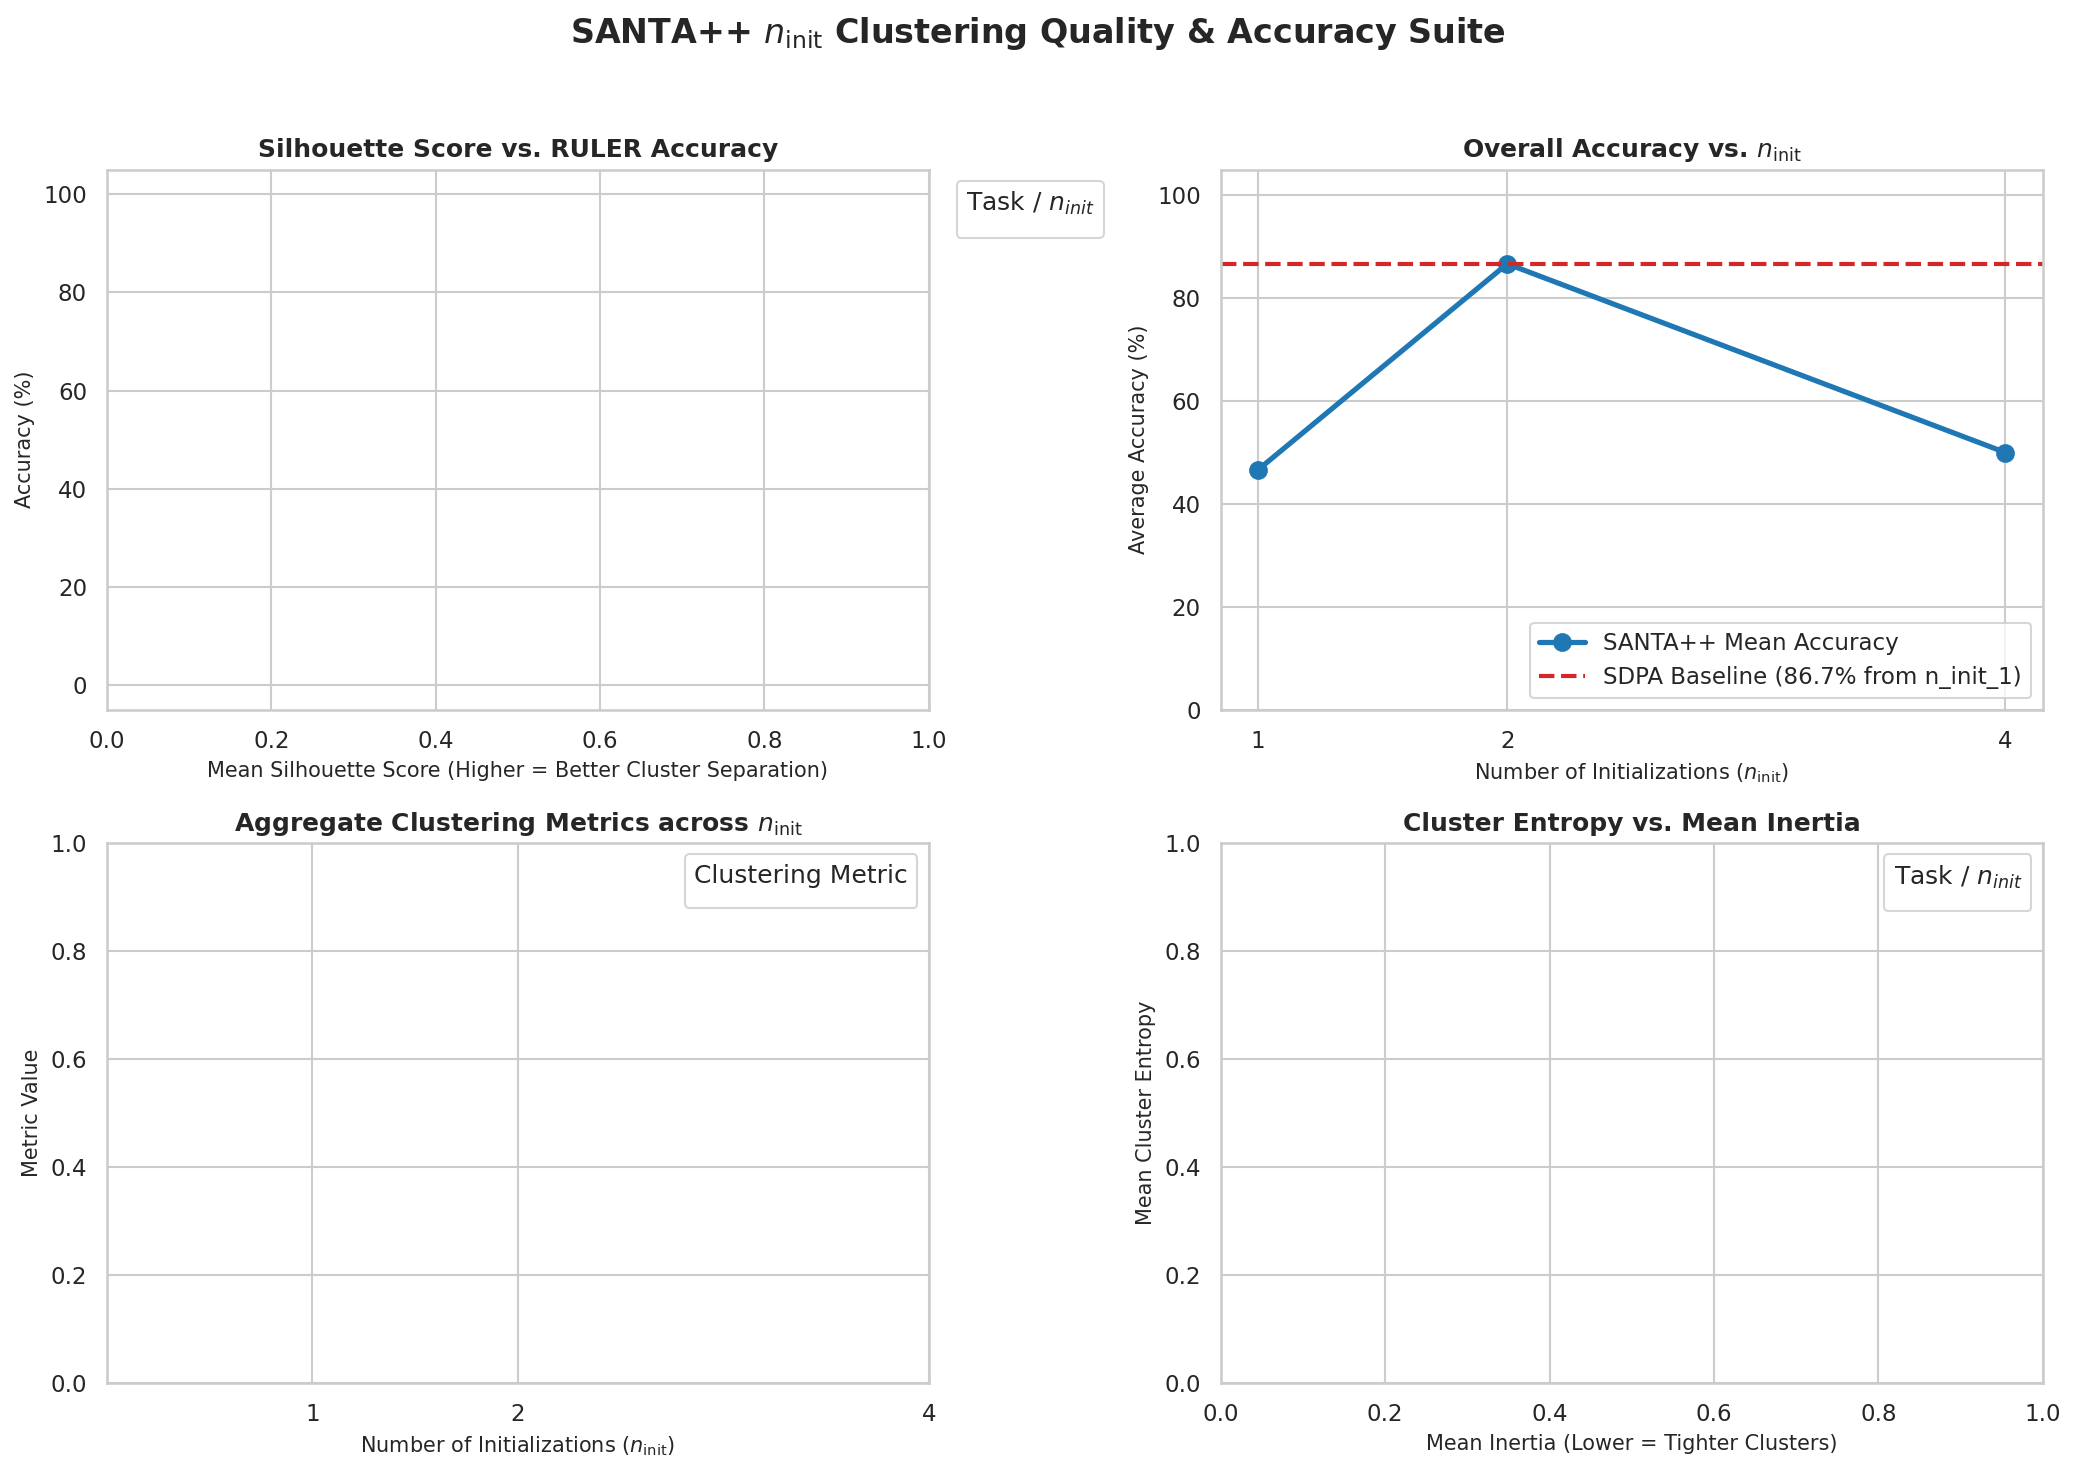

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150

# ==============================================================================
# 1. Parse Directory Structure & Clustering Metrics
# ==============================================================================
SWEEP_DIR = Path("./benchmarks/full-n-init-sweep")

records = []
sdpa_overall_acc = None

for run_dir in sorted(SWEEP_DIR.glob("n_init_*")):
    if not run_dir.is_dir():
        continue

    try:
        n_init = int(run_dir.name.split("_")[-1])
    except ValueError:
        continue

    summary_file = run_dir / "summary.json"
    if not summary_file.exists():
        continue

    try:
        with open(summary_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Pull SDPA baseline ONLY from n_init_1
        if n_init == 1 and "sdpa" in data.get("backends", {}):
            sdpa_overall_acc = data["backends"]["sdpa"].get("aggregate", {}).get("score", None)

        santapp_data = data["backends"]["santapp"]

        # Parse task-level metrics for SANTA++
        for task_name, task_metrics in santapp_data.get("tasks", {}).items():
            if task_name in ["__selected_task_mean__", "aggregate"]:
                continue

            # Fallback to check either root task_metrics or nested dict
            ms = task_metrics.get("metrics_summary", task_metrics)

            records.append({
                "n_init": n_init,
                "task": task_name,
                "accuracy": float(task_metrics.get("score", 0.0)),
                "inertia": ms.get("mean_inertia"),
                "calinski_harabasz": ms.get("mean_calinski_harabasz"),
                "davies_bouldin": ms.get("mean_davies_bouldin"),
                "silhouette": ms.get("mean_silhouette"),
                "cluster_entropy": ms.get("mean_cluster_entropy"),
                "clustering_time": float(task_metrics.get("mean_clustering_seconds", 0.0)),
                "decode_time": float(task_metrics.get("mean_decode_seconds", 0.0)),
                "type": "Per-Task"
            })

        # Parse aggregate summary for SANTA++
        agg = santapp_data.get("aggregate", {})
        agg_ms = agg.get("metrics_summary", agg)

        records.append({
            "n_init": n_init,
            "task": "Aggregate Mean",
            "accuracy": float(agg.get("score", 0.0)),
            "inertia": agg_ms.get("mean_inertia"),
            "calinski_harabasz": agg_ms.get("mean_calinski_harabasz"),
            "davies_bouldin": agg_ms.get("mean_davies_bouldin"),
            "silhouette": agg_ms.get("mean_silhouette"),
            "cluster_entropy": agg_ms.get("mean_cluster_entropy"),
            "clustering_time": float(agg.get("mean_clustering_seconds", 0.0)),
            "decode_time": float(agg.get("mean_decode_seconds", 0.0)),
            "type": "Aggregate"
        })

    except Exception as e:
        print(f"Error reading {summary_file}: {e}")

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError(f"No valid run data found in {SWEEP_DIR.resolve()}")

# ==============================================================================
# 2. Diagnostic Plot Suite (Display Only, No PNG Export)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SANTA++ $n_{\\text{init}}$ Clustering Quality & Accuracy Suite", fontsize=16, fontweight="bold", y=0.98)

task_df = df[df["type"] == "Per-Task"]
agg_df = df[df["type"] == "Aggregate"]

# ------------------------------------------------------------------------------
# PLOT 1: Silhouette Score vs. RULER Accuracy
# ------------------------------------------------------------------------------
ax1 = axes[0, 0]
sns.scatterplot(
    data=task_df,
    x="silhouette",
    y="accuracy",
    hue="task",
    style="n_init",
    s=130,
    palette="Set2",
    ax=ax1
)

ax1.set_title("Silhouette Score vs. RULER Accuracy", fontsize=12, fontweight="bold")
ax1.set_xlabel("Mean Silhouette Score (Higher = Better Cluster Separation)", fontsize=10)
ax1.set_ylabel("Accuracy (%)", fontsize=10)
ax1.set_ylim(-5, 105)
ax1.legend(title="Task / $n_{init}$", bbox_to_anchor=(1.02, 1), loc="upper left")

# ------------------------------------------------------------------------------
# PLOT 2: RULER Accuracy vs. n_init Count
# ------------------------------------------------------------------------------
ax2 = axes[0, 1]
ax2.plot(
    agg_df["n_init"],
    agg_df["accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4",
    label="SANTA++ Mean Accuracy"
)

if sdpa_overall_acc is not None:
    ax2.axhline(
        y=sdpa_overall_acc,
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label=f"SDPA Baseline ({sdpa_overall_acc:.1f}% from n_init_1)"
    )

ax2.set_xticks(agg_df["n_init"].unique())
ax2.set_title("Overall Accuracy vs. $n_{\\text{init}}$", fontsize=12, fontweight="bold")
ax2.set_xlabel("Number of Initializations ($n_{\\text{init}}$)", fontsize=10)
ax2.set_ylabel("Average Accuracy (%)", fontsize=10)
ax2.set_ylim(0, 105)
ax2.legend(loc="lower right")

# ------------------------------------------------------------------------------
# PLOT 3: Cluster Quality Metrics across n_init
# ------------------------------------------------------------------------------
ax3 = axes[1, 0]
metric_cols = ["silhouette", "davies_bouldin", "cluster_entropy", "calinski_harabasz"]

metrics_melted = agg_df.melt(
    id_vars=["n_init"], 
    value_vars=[c for c in metric_cols if agg_df[c].notna().any()],
    var_name="Metric", 
    value_name="Value"
)

sns.lineplot(
    data=metrics_melted,
    x="n_init",
    y="Value",
    hue="Metric",
    marker="s",
    linewidth=2,
    palette="Dark2",
    ax=ax3
)

ax3.set_xticks(agg_df["n_init"].unique())
ax3.set_title("Aggregate Clustering Metrics across $n_{\\text{init}}$", fontsize=12, fontweight="bold")
ax3.set_xlabel("Number of Initializations ($n_{\\text{init}}$)", fontsize=10)
ax3.set_ylabel("Metric Value", fontsize=10)
ax3.legend(title="Clustering Metric")

# ------------------------------------------------------------------------------
# PLOT 4: Cluster Entropy vs. Inertia per Task
# ------------------------------------------------------------------------------
ax4 = axes[1, 1]
sns.scatterplot(
    data=task_df,
    x="inertia",
    y="cluster_entropy",
    hue="task",
    size="n_init",
    sizes=(60, 160),
    palette="Set2",
    ax=ax4
)

ax4.set_title("Cluster Entropy vs. Mean Inertia", fontsize=12, fontweight="bold")
ax4.set_xlabel("Mean Inertia (Lower = Tighter Clusters)", fontsize=10)
ax4.set_ylabel("Mean Cluster Entropy", fontsize=10)
ax4.legend(title="Task / $n_{init}$")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()